
Final Output:

        bmi        bp  Cluster           Category
0  6.169621  2.187239        0   High BMI, Low BP
1 -5.147406 -2.632753        2    Low BMI, Low BP
2  4.445121 -0.567042        0   High BMI, Low BP
3 -1.159501 -3.665608        2    Low BMI, Low BP
4 -3.638469  2.187239        2    Low BMI, Low BP
5 -4.069594 -1.944183        2    Low BMI, Low BP
6 -4.716281 -1.599898        2    Low BMI, Low BP
7 -0.189471  6.662945        1  High BMI, High BP
8  6.169621 -4.009893        0   High BMI, Low BP
9  3.906215 -3.321323        0   High BMI, Low BP

Centroid Interpretation:

Cluster 0: BMI=5.37, BP=-1.93
Cluster 1: BMI=2.37, BP=5.71
Cluster 2: BMI=-3.38, BP=-2.83


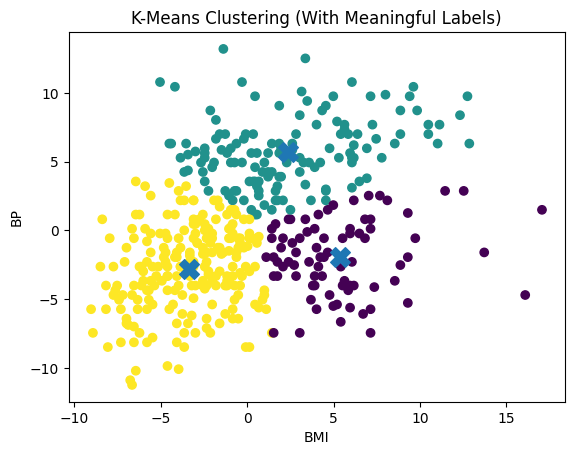

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
data_obj = load_diabetes()
data = pd.DataFrame(data_obj.data, columns=data_obj.feature_names)

# Use only 2 columns
data = data[['bmi', 'bp']]

# Scale values (for clarity)
data = data * 100

# Save CSV
data.to_csv("simple_data.csv", index=False)

# Apply k-means
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(data)

# Add cluster numbers
data['Cluster'] = kmeans.labels_

# Get centroids
centroids = kmeans.cluster_centers_

# 🔹 Convert clusters to labels
labels = []

for i in data['Cluster']:
    bmi_val = centroids[i][0]
    bp_val = centroids[i][1]

    if bmi_val > 0 and bp_val > 0:
        labels.append("High BMI, High BP")
    elif bmi_val > 0 and bp_val < 0:
        labels.append("High BMI, Low BP")
    elif bmi_val < 0 and bp_val > 0:
        labels.append("Low BMI, High BP")
    else:
        labels.append("Low BMI, Low BP")

data['Category'] = labels

# Print clean table
print("\nFinal Output:\n")
print(data.head(10))

# Print centroid meaning
print("\nCentroid Interpretation:\n")
for i, c in enumerate(centroids):
    print(f"Cluster {i}: BMI={round(c[0],2)}, BP={round(c[1],2)}")

# Graph
plt.scatter(data['bmi'], data['bp'], c=data['Cluster'])

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)

plt.xlabel("BMI")
plt.ylabel("BP")
plt.title("K-Means Clustering (With Meaningful Labels)")
plt.show()